# 환경 설정
- GPU 사용 설정  
- 필요 라이브러리 설치

    1. `segmentation-models-pytorch` - **이미지 분할(Segmentation) 모델**을 제공하는 라이브러리
        - **주요 기능**  : ResNet, VGG, EfficientNet, Unet, FPN, PSPNet 등 사전 학습된 모델을 지원
        - **사용 예**: 의료 영상 분할, 자율 주행차의 도로 영역 탐지, 위성 이미지의 토지 분류 등

    2. `albumentations` -  **데이터 증강(Data Augmentation)**을 쉽게 수행할 수 있도록 설계된 라이브러리
        - **주요 기능**  :  **이미지 회전, 자르기, 확대, 밝기 조정, 노이즈 추가 등** 다양한 변환을 수행
        - **사용 예**: 이미지 분류, 객체 탐지, 이미지 분할 등의 데이터 증강을 통해 모델의 일반화 성능을 높이기 위해 사용

    3. `opencv-contrib-python` - **이미지 처리** 라이브러리
        - **주요 기능**  : 다양한 이미지/동영상 처리 함수 및 **엣지 검출, 필터링, 형태 변환, 객체 추적** 등 고급 이미지 처리 기능 제공  
        - **사용 예**: 객체 검출, 이미지 필터링, 동영상 분석, AR(Augmented Reality), 머신러닝 기반의 컴퓨터 비전 작업 등

In [1]:
!pip install segmentation-models-pytorch
!pip install -U git+https://github.com/albumentations-team/albumentations
!pip install --upgrade opencv-contrib-python

  Cloning https://github.com/albumentations-team/albumentations to /tmp/pip-req-build-mzyxkpaa
  Running command git clone --filter=blob:none --quiet https://github.com/albumentations-team/albumentations /tmp/pip-req-build-mzyxkpaa
  Resolved https://github.com/albumentations-team/albumentations to commit 3ed63f2513affb2dc53c1cfcc962e08ed86c8c62
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done


In [2]:
!git clone https://github.com/parth1620/Human-Segmentation-Dataset-master.git

fatal: destination path 'Human-Segmentation-Dataset-master' already exists and is not an empty directory.


In [3]:
import sys
sys.path.append('/content/Human-Segmentation-Dataset-master')

In [4]:
import torch
import cv2
import os

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from tqdm import tqdm

import helper

### Configuration setup

In [5]:
CSV_FILE = '/content/Human-Segmentation-Dataset-master/train.csv'
DATA_DIR = '/content/'

EPOCHS = 25
LEARNING_RATE = 0.003
IMAGE_SIZE = 320

#ENCODER = "timm-efficientnet-b0"
ENCODER = "resnet18"
WEIGHTS = "imagenet"
BATCH_SIZE = 16

DEVICE = "cuda:0" if torch.cuda.is_available() else "cpu"
print(DEVICE)

cuda:0


In [6]:
df = pd.read_csv(CSV_FILE)
df.head()

,masks,images
0,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
1,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
2,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
3,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...
4,Human-Segmentation-Dataset-master/Ground_Truth...,Human-Segmentation-Dataset-master/Training_Ima...


In [7]:
row = df.iloc[0]

# 이미지 및 마스크 경로 설정
image_path = os.path.join(DATA_DIR, row.images)
mask_path = os.path.join(DATA_DIR, row.masks)

# 이미지 읽기 및 RGB로 변환
image = cv2.imread(image_path)  # 이미지 파일 읽기
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)  # BGR을 RGB로 변환

# 마스크 읽기 및 정규화 (0과 1 사이 값으로 변환)
mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE) / 255.0  # 그레이스케일로 읽고 255로 나눠서 정규화

# 이미지와 마스크의 크기 출력
print(image.shape)
print(mask.shape)

(183, 276, 3)
(183, 276)


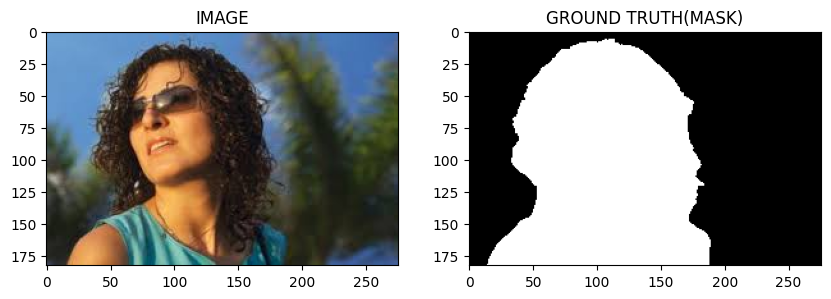

In [8]:
f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

ax1.set_title('IMAGE')
ax1.imshow(image)

ax2.set_title('GROUND TRUTH(MASK)')
ax2.imshow(mask, cmap='gray')

In [9]:
# 학습용 데이터와 검증용 데이터로 분할
train_df, valid_df = train_test_split(df, test_size=0.2, random_state=42)  # 데이터의 20%를 검증용으로 분리
train_df.shape, valid_df.shape

((232, 2), (58, 2))

### Data Augmentation (데이터 증강)

albumentation documentation : https://albumentations.ai/docs/

In [10]:
import albumentations as A

# 학습 데이터 증강 설정
train_augs = A.Compose([
        A.Resize(IMAGE_SIZE, IMAGE_SIZE),  # 이미지 크기를 IMAGE_SIZE x IMAGE_SIZE로 리사이즈
        A.HorizontalFlip(p=0.5),  # 50% 확률로 이미지 수평 뒤집기
        A.VerticalFlip(p=0.5)       # 50% 확률로 이미지 수직 뒤집기
    ])

# 검증 데이터 증강 설정
valid_augs = A.Compose([
        A.Resize(IMAGE_SIZE, IMAGE_SIZE)  # 이미지 크기를 IMAGE_SIZE x IMAGE_SIZE로 리사이즈
    ])

### 사용자 정의 Dataset 생성

In [12]:
from torch.utils.data import Dataset

class SegmentationDataset(Dataset):
    def __init__(self, df, augmentations):
        self.df = df  # 데이터프레임 저장
        self.augmentations = augmentations  # 증강 기법 저장

    def __len__(self):
        return len(self.df)  # 데이터셋의 총 샘플 수 반환

    def __getitem__(self, idx):
        # 주어진 인덱스에 해당하는 데이터 가져오기
        row = self.df.iloc[idx]
        image_path = os.path.join(DATA_DIR, row.images)  # 이미지 경로 설정
        mask_path = os.path.join(DATA_DIR, row.masks)  # 마스크 경로 설정

        # 이미지 읽기 및 RGB로 변환
        image = cv2.imread(image_path)
        image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

        # 이미지 크기 가져오기
        desired_height, desired_width = image.shape[:2]

        # 마스크 읽기, 그레이스케일로 로드 후 리사이즈
        mask = cv2.imread(mask_path, cv2.IMREAD_GRAYSCALE)  # (h, w)
        mask = cv2.resize(mask, (desired_width, desired_height))  # 이미지 크기에 맞춰 마스크 리사이즈
        mask = np.expand_dims(mask, axis=-1)            # 마스크에 채널 차원 추가 (h, w, 1)

        # 증강 적용
        if self.augmentations:
            data = self.augmentations(image=image, mask=mask)
            image = data['image']
            mask = data['mask']

        # 이미지와 마스크의 차원 변환: (h, w, c) -> (c, h, w)
        image = np.transpose(image, (2, 0, 1)).astype(np.float32)
        mask = np.transpose(mask, (2, 0, 1)).astype(np.float32)

        # 이미지 및 마스크 정규화
        image = torch.tensor(image) / 255.0                   # 이미지 값을 0-1 범위로 정규화
        mask = torch.round(torch.tensor(mask) / 255.0)  # 마스크 값을 0 또는 1로 정규화 후 반올림

        return image, mask  # 이미지와 마스크 반환

In [13]:
# 학습용 및 검증용 데이터셋 생성
trainset = SegmentationDataset(train_df, train_augs)  # 학습 데이터셋 생성, 데이터 증강 포함
validset = SegmentationDataset(valid_df, valid_augs)  # 검증 데이터셋 생성, 검증 증강 포함

# 학습 데이터셋과 검증 데이터셋의 샘플 수 출력
len(trainset), len(validset)

(232, 58)

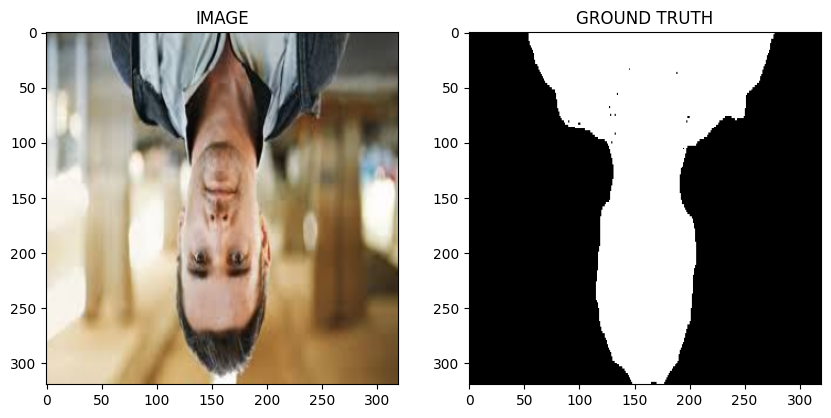

In [14]:
# 샘플 인덱스 설정
idx = 32

# 학습 데이터셋에서 인덱스에 해당하는 이미지와 마스크 가져오기
image, mask = trainset[idx]

f, (ax1, ax2) = plt.subplots(1, 2, figsize=(10,5))

# 첫 번째 서브플롯에 이미지 출력
ax1.set_title('IMAGE')
ax1.imshow(image.permute(1, 2, 0))  # (c, h, w)를 (h, w, c)로 변환하여 이미지 표시

# 두 번째 서브플롯에 마스크(GROUND TRUTH) 출력
ax2.set_title('GROUND TRUTH')
ax2.imshow(mask.permute(1, 2, 0).squeeze(), cmap='gray')  # 마스크를 회색조(cmap='gray')로 표시

plt.show()

### 데이터 로더 작성

In [15]:
from torch.utils.data import DataLoader

# 학습용 데이터 로더 생성
train_loader = DataLoader(trainset, batch_size=BATCH_SIZE, shuffle=True)  # 학습 데이터 로더, 배치 크기 설정 및 셔플 활성화

# 검증용 데이터 로더 생성
valid_loader = DataLoader(validset, batch_size=BATCH_SIZE)  # 검증 데이터 로더, 배치 크기 설정

# 전체 배치 수 출력
len(train_loader), len(valid_loader)

(15, 4)

In [16]:
for image, mask in train_loader:
    print(image.shape)
    print(mask.shape)
    break

torch.Size([16, 3, 320, 320])
torch.Size([16, 1, 320, 320])


### Segmentation Model 작성

segmentation_models_pytorch documentation : https://smp.readthedocs.io/en/latest/

In [17]:
from torch import nn
 # 이미지 분할 모델을 제공하는 segmentation_models_pytorch 라이브러리 임포트
import segmentation_models_pytorch as smp
# 분할 작업에 자주 사용되는 Dice 손실 함수 임포트
from segmentation_models_pytorch.losses import DiceLoss

In [18]:
class SegmentationModel(nn.Module):
    def __init__(self):
        super().__init__()

        # Unet 아키텍처 초기화
        self.architecture = smp.Unet(
            encoder_name=ENCODER,     # 인코더 이름 설정
            encoder_weights=WEIGHTS,   # 사전 학습된 가중치 사용 ('imagenet')
            in_channels=3,                        # 입력 이미지 채널 수 (RGB이므로 3 채널)
            classes=1,                               # 출력 클래스 수 (이진 분할이므로 1 클래스)
            activation=None                      # 마지막 레이어에 활성화 함수 사용 안 함
        )

    def forward(self, images, masks=None):
        # 입력 이미지를 모델에 통과시켜 예측값(logits) 생성
        logits = self.architecture(images)

        # 마스크가 주어졌다면 (훈련 모드)
        if masks is not None:
            # Dice 손실 계산
            loss1 = DiceLoss(mode='binary')(logits, masks)
            # Binary Cross Entropy 손실 계산
            loss2 = nn.BCEWithLogitsLoss()(logits, masks)
            # 두 손실을 더해서 반환 (훈련 시 사용)
            return logits, loss1 + loss2

        # 마스크가 없을 때는 예측값만 반환 (추론 시 사용)
        return logits

In [19]:
model = SegmentationModel()
model.to(DEVICE)

Downloading: "https://download.pytorch.org/models/resnet18-5c106cde.pth" to /root/.cache/torch/hub/checkpoints/resnet18-5c106cde.pth
100%|██████████| 44.7M/44.7M [00:00<00:00, 245MB/s]


SegmentationModel(
  (architecture): Unet(
    (encoder): ResNetEncoder(
      (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
      (layer1): Sequential(
        (0): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
          (relu): ReLU(inplace=True)
          (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
          (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
        )
        (1): BasicBlock(
          (conv1): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
       

### Train and Validation 함수 작성

In [20]:
def train_fn(data_loader, model, optimizer):
    model.train()        # 모델을 학습 모드로 설정
    total_loss = 0       # 총 손실 초기화

    # 데이터 로더에서 이미지와 마스크를 가져와 학습
    for images, masks in tqdm(data_loader):

        # 이미지를 지정한 장치(DEVICE)로 이동
        images = images.to(DEVICE)
        masks = masks.to(DEVICE)

        # 옵티마이저의 그래디언트 초기화
        optimizer.zero_grad()
        # 모델에 이미지를 입력하여 예측값과 손실 계산
        logits, loss = model(images, masks)
        # 손실의 그래디언트를 계산하고 역전파
        loss.backward()
        # 옵티마이저를 통해 가중치 업데이트
        optimizer.step()

        # 현재 배치의 손실을 총 손실에 더하기
        total_loss += loss.item()

    # 평균 손실 반환
    return total_loss / len(data_loader)

In [21]:
def eval_fn(data_loader, model):
    model.eval()       # 모델을 평가 모드로 설정
    total_loss = 0     # 총 손실 초기화

    # 그래디언트 계산 비활성화
    with torch.no_grad():
        # 데이터 로더에서 이미지와 마스크를 가져와 평가
        for images, masks in tqdm(data_loader):

            # 이미지를 지정한 장치(DEVICE)로 이동
            images = images.to(DEVICE)
            masks = masks.to(DEVICE)

            # 모델에 이미지를 입력하여 예측값과 손실 계산
            logits, loss = model(images, masks)

            # 현재 배치의 손실을 총 손실에 더하기
            total_loss += loss.item()

    # 평균 손실 반환
    return total_loss / len(data_loader)

### Model Train

In [22]:
# Adam 옵티마이저 초기화
optimizer = torch.optim.Adam(model.parameters(), lr=LEARNING_RATE)  # 학습률 설정

# 최적 검증 손실 초기값을 무한대로 설정
best_valid_loss = np.Inf

# 학습을 EPOCHS만큼 반복
for i in range(EPOCHS):

    # 학습 데이터셋을 사용하여 모델 학습
    train_loss = train_fn(train_loader, model, optimizer)

    # 검증 데이터셋을 사용하여 모델 평가
    valid_loss = eval_fn(valid_loader, model)

    # 검증 손실이 이전 최적 손실보다 낮으면 모델 저장
    if valid_loss < best_valid_loss:
        torch.save(model.state_dict(), 'best_model.pt')     # 최적 모델 저장
        print("Better model saved...")
        best_valid_loss = valid_loss        # 최적 검증 손실 갱신

    # 현재 에포크의 학습 손실과 검증 손실 출력
    print(f"Epoch : {i+1} Train_Loss: {train_loss},  Valid_Loss: {valid_loss}")

100%|██████████| 4/4 [00:00<00:00,  4.47it/s]


Better model saved...
Epoch : 1 Train_Loss: 1.0586044152577718,  Valid_Loss: 38.95352077484131


100%|██████████| 4/4 [00:00<00:00,  6.23it/s]


Better model saved...
Epoch : 2 Train_Loss: 0.807834776242574,  Valid_Loss: 2.8300359547138214


100%|██████████| 4/4 [00:00<00:00,  5.87it/s]


...

Better model saved...
Epoch : 23 Train_Loss: 0.2890398263931274,  Valid_Loss: 0.3024185225367546


100%|██████████| 4/4 [00:00<00:00,  4.78it/s]


Epoch : 24 Train_Loss: 0.26592324376106263,  Valid_Loss: 0.4004647359251976


100%|██████████| 4/4 [00:00<00:00,  6.50it/s]

Epoch : 25 Train_Loss: 0.2830003599325816,  Valid_Loss: 0.4692390114068985


### Inference

In [23]:
idx = 2  # 예측할 검증 데이터셋의 인덱스 설정

# 저장된 최적 모델의 가중치 로드
model.load_state_dict(torch.load('/content/best_mode.pt'))

# 검증 데이터셋에서 이미지와 마스크 가져오기
image, mask = validset[idx]

# 모델을 사용하여 예측 마스크 생성 (차원을 맞추기 위해 unsqueeze 사용)
logits_mask = model(image.to(DEVICE).unsqueeze(0))  # (C, H, W) => (1, C, H, W)

# 예측값에 시그모이드 함수를 적용하여 확률 값으로 변환
pred_mask = torch.sigmoid(logits_mask)

# 0.5를 기준으로 이진화하여 최종 예측 마스크 생성
pred_mask = (pred_mask > 0.5) * 1.0  # 0.5보다 크면 1.0, 아니면 0.0

<ipython-input-23-940a34212f2e>:3: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model.load_state_dict(torch.load('/content/best_mode.pt'))


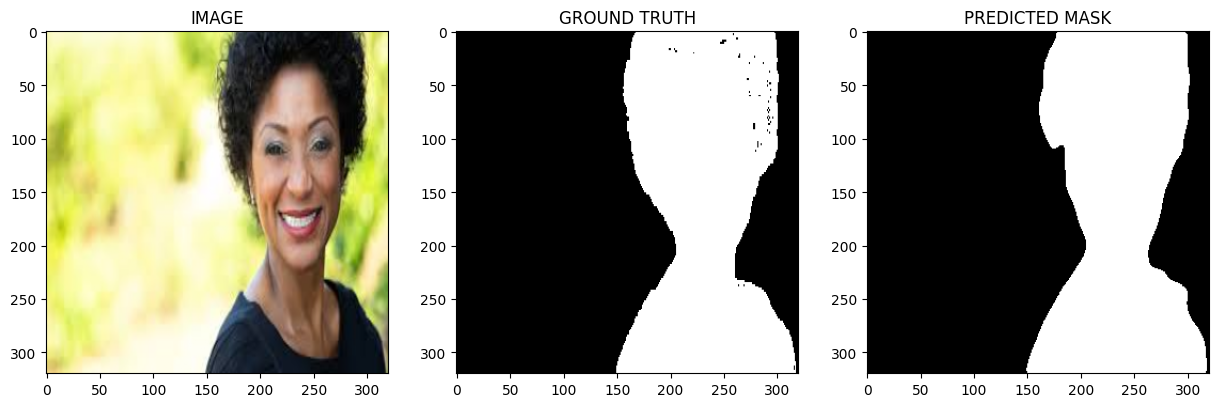

In [24]:
f, (ax1, ax2, ax3) = plt.subplots(1, 3, figsize=(15, 5))

# 첫 번째 서브플롯에 원본 이미지 출력
ax1.set_title('IMAGE')
ax1.imshow(image.permute(1, 2, 0))  # (C, H, W)를 (H, W, C)로 변환하여 이미지 표시

# 두 번째 서브플롯에 실제 마스크(GROUND TRUTH) 출력
ax2.set_title('GROUND TRUTH')
ax2.imshow(mask.permute(1, 2, 0).squeeze(), cmap='gray')  # 마스크를 회색조로 표시

# 세 번째 서브플롯에 예측 마스크(PREDICTED MASK) 출력
ax3.set_title('PREDICTED MASK')
pred_mask = pred_mask.to("cpu").squeeze(0)  # 예측 마스크를 CPU로 이동하고 첫 번째 차원 제거
ax3.imshow(pred_mask.permute(1, 2, 0).squeeze(), cmap='gray')  # 예측 마스크를 회색조로 표시

plt.show()